## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов.

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки.

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины.

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [2]:
df = pd.read_parquet('hw_1_marketplace_data.parquet')

In [3]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику.
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

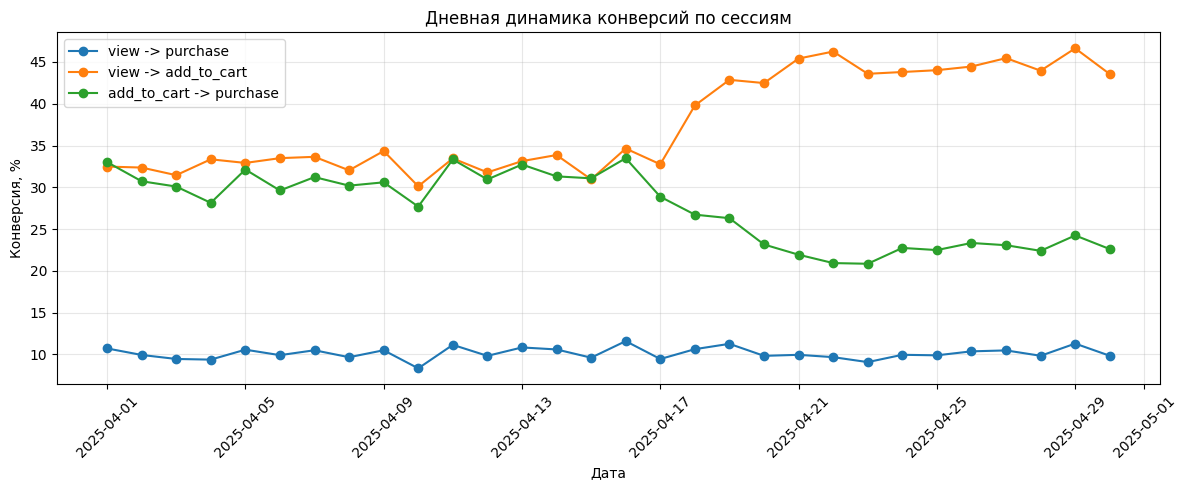

,до 18.04,с 18.04
event,,
view_to_purchase,10.1,10.2
view_to_cart,32.7,44.0
cart_to_purchase,30.9,23.1


In [4]:
df['date'] = df['event_ts'].dt.date

funnel_events = ['view_item', 'add_to_cart', 'purchase']

funnel = (
    df[df['event'].isin(funnel_events)]
    .groupby(['date', 'event'])['session_id']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

funnel['view_to_purchase'] = funnel['purchase'] / funnel['view_item']
funnel['view_to_cart'] = funnel['add_to_cart'] / funnel['view_item']
funnel['cart_to_purchase'] = funnel['purchase'] / funnel['add_to_cart']

plt.figure(figsize=(12, 5))
for col, label in [
    ('view_to_purchase', 'view -> purchase'),
    ('view_to_cart', 'view -> add_to_cart'),
    ('cart_to_purchase', 'add_to_cart -> purchase')
]:
    plt.plot(funnel['date'], funnel[col] * 100, marker='o', label=label)

plt.title('Дневная динамика конверсий по сессиям')
plt.ylabel('Конверсия, %')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

cutoff = pd.Timestamp('2025-04-18').date()
metrics = ['view_to_purchase', 'view_to_cart', 'cart_to_purchase']
summary = pd.DataFrame({
    'до 18.04': funnel[funnel['date'] < cutoff][metrics].mean() * 100,
    'с 18.04': funnel[funnel['date'] >= cutoff][metrics].mean() * 100
}).round(1)
summary


**Вывод.** До 18 апреля на графике все выглядит более-менее стабильно. Потом видно резкое изменение именно в метриках, связанных с корзиной. `view -> add_to_cart` выросла примерно с 33% до 44%, а `add_to_cart -> purchase`, наоборот, упала примерно с 31% до 23%.

При этом `view -> purchase` почти не изменилась и остается около 10%. Поэтому я бы не сказал, что пользователи стали хуже покупать в целом. Скорее с 18 апреля что-то изменилось именно на этапе добавления товара в корзину. После этого метрики уже держатся примерно на новом уровне, то есть это не постепенное падение, а какой-то резкий сдвиг.

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя.
3) На каком этапе воронки появилась проблема?

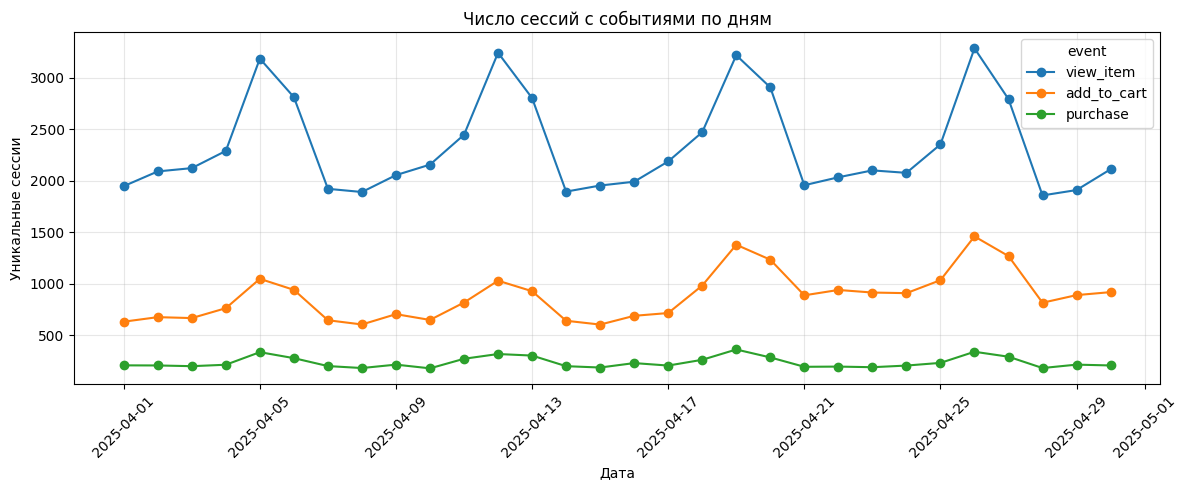

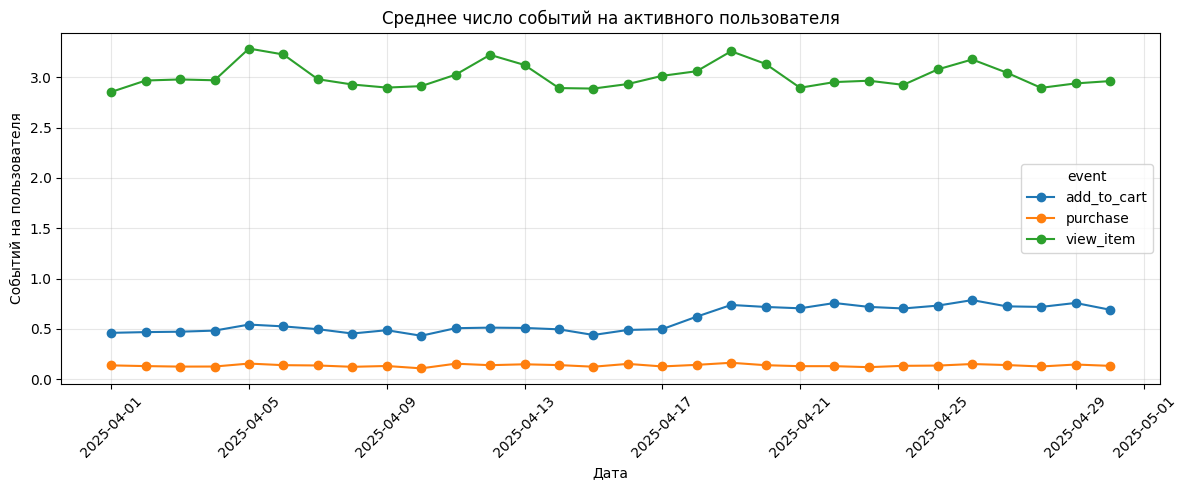

,до 18.04,с 18.04
event,,
add_to_cart,0.487,0.721
purchase,0.136,0.138
view_item,3.006,3.022


In [5]:
absolute_sessions = funnel[['date', 'view_item', 'add_to_cart', 'purchase']].copy()

absolute_sessions.plot(
    x='date',
    y=['view_item', 'add_to_cart', 'purchase'],
    figsize=(12, 5),
    marker='o'
)
plt.title('Число сессий с событиями по дням')
plt.ylabel('Уникальные сессии')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Считаю среднее число событий на одного пользователя
active_users = df.groupby('date')['user_id'].nunique()
event_counts = (
    df[df['event'].isin(funnel_events)]
    .groupby(['date', 'event'])
    .size()
    .unstack(fill_value=0)
)

avg_events_per_user = event_counts.div(active_users, axis=0)

avg_events_per_user.plot(figsize=(12, 5), marker='o')
plt.title('Среднее число событий на активного пользователя')
plt.ylabel('Событий на пользователя')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

avg_summary = pd.DataFrame({
    'до 18.04': avg_events_per_user.loc[avg_events_per_user.index < cutoff].mean(),
    'с 18.04': avg_events_per_user.loc[avg_events_per_user.index >= cutoff].mean()
}).round(3)
avg_summary


**Вывод.** Если посмотреть уже не на конверсии, а на сами значения, то просмотры и покупки не показывают какого-то сильного изменения. Зато `add_to_cart` после 18 апреля заметно вырос.

Та же картина получается, если считать среднее количество событий на пользователя: add_to_cart стало намного больше, а `view_item` и `purchase` сильно не поменялись.

Получается, проблема находится именно около добавления товара в корзину. Из-за того, что добавлений стало больше, знаменатель в `add_to_cart -> purchase` вырос, поэтому сама конверсия упала, хотя количество покупок при этом не обвалилось.

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

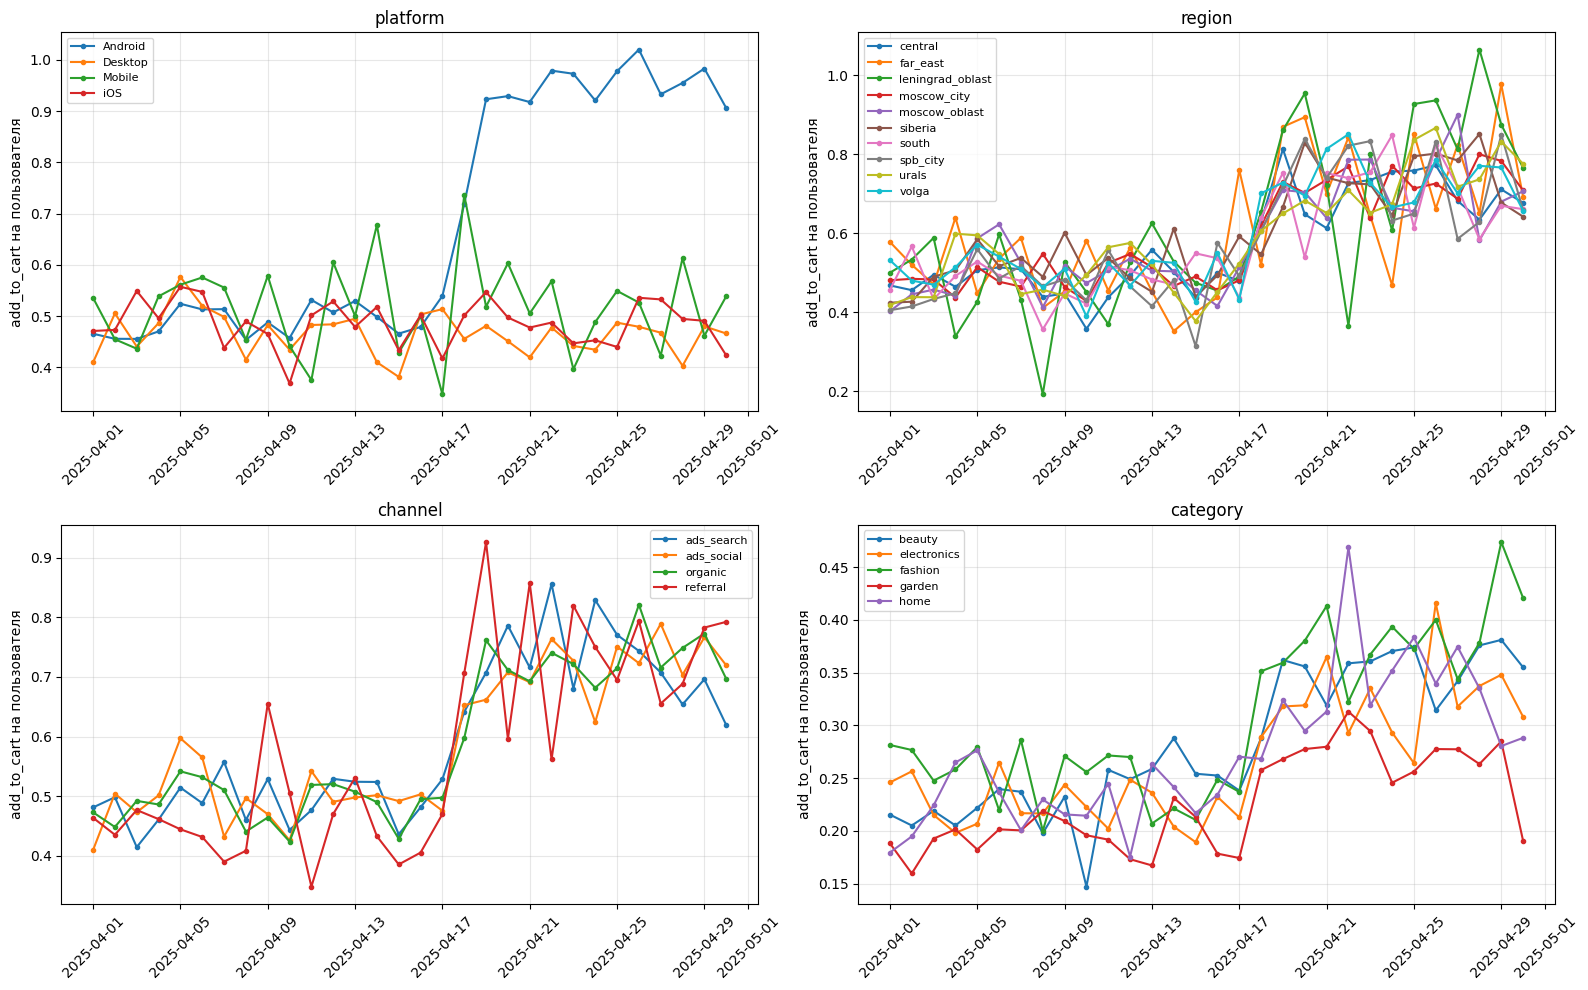

,до 18.04,с 18.04
platform,,
Android,0.491,0.934
Desktop,0.473,0.457
Mobile,0.504,0.533
iOS,0.484,0.486


In [6]:
def avg_event_by_slice(data, event_name, slice_col):
    users = data.groupby(['date', slice_col])['user_id'].nunique().rename('users')
    events = (
        data[data['event'] == event_name]
        .groupby(['date', slice_col])
        .size()
        .rename('events')
    )

    result = pd.concat([users, events], axis=1).fillna({'events': 0}).reset_index()
    result['avg_per_user'] = result['events'] / result['users']
    return result

slices = ['platform', 'region', 'channel', 'category']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.ravel(), slices):
    data_slice = df.copy()
    if col == 'category':
        data_slice = data_slice[data_slice['category'] != 'None']

    tmp = avg_event_by_slice(data_slice, 'add_to_cart', col)
    pivot = tmp.pivot(index='date', columns=col, values='avg_per_user')

    for name in pivot.columns:
        ax.plot(pivot.index, pivot[name], marker='o', markersize=3, label=name)

    ax.set_title(col)
    ax.set_ylabel('add_to_cart на пользователя')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Отдельно сравниваю платформы до и после 18 апреля
platform_avg = avg_event_by_slice(df, 'add_to_cart', 'platform')
before = (
    platform_avg[platform_avg['date'] < cutoff]
    .groupby('platform')['avg_per_user']
    .mean()
)
after = (
    platform_avg[platform_avg['date'] >= cutoff]
    .groupby('platform')['avg_per_user']
    .mean()
)
platform_summary = pd.concat([before, after], axis=1)
platform_summary.columns = ['до 18.04', 'с 18.04']
platform_summary.round(3)


**Вывод.** Здесь сильнее всего выделяется Android. После 18 апреля среднее количество add_to_cart на пользователя на Android выросло примерно с 0.49 до 0.93, то есть почти в два раза.


#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

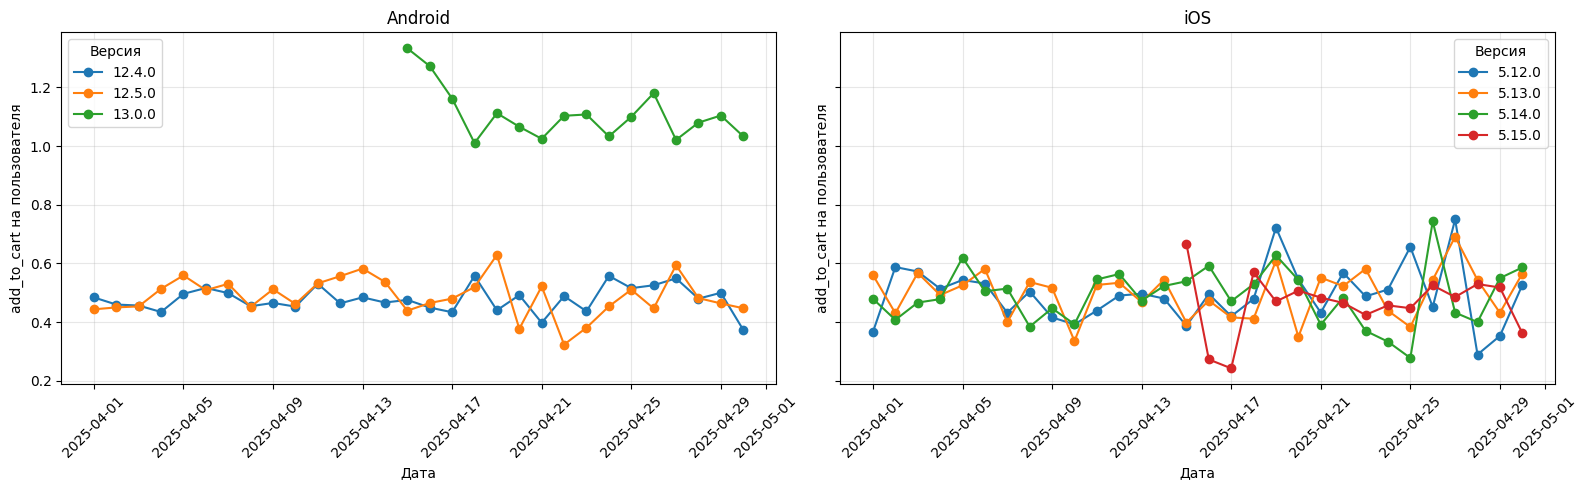

platform  app_version
Android   12.4.0         0.486
          12.5.0         0.473
          13.0.0         1.075
iOS       5.12.0         0.521
          5.13.0         0.510
          5.14.0         0.482
          5.15.0         0.480
Name: avg_per_user, dtype: float64

In [7]:
mobile_df = df[df['platform'].isin(['Android', 'iOS'])].copy()

users = (
    mobile_df.groupby(['date', 'platform', 'app_version'])['user_id']
    .nunique()
    .rename('users')
)
cart_events = (
    mobile_df[mobile_df['event'] == 'add_to_cart']
    .groupby(['date', 'platform', 'app_version'])
    .size()
    .rename('events')
)

version_cart = pd.concat([users, cart_events], axis=1).fillna({'events': 0}).reset_index()
version_cart['avg_per_user'] = version_cart['events'] / version_cart['users']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, ['Android', 'iOS']):
    tmp = version_cart[version_cart['platform'] == platform]
    pivot = tmp.pivot(index='date', columns='app_version', values='avg_per_user')

    for version in pivot.columns:
        ax.plot(pivot.index, pivot[version], marker='o', label=version)

    ax.set_title(platform)
    ax.set_ylabel('add_to_cart на пользователя')
    ax.set_xlabel('Дата')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(title='Версия')

plt.tight_layout()
plt.show()

version_summary = (
    version_cart[version_cart['date'] >= cutoff]
    .groupby(['platform', 'app_version'])['avg_per_user']
    .mean()
    .round(3)
)
version_summary


**Вывод.** Разбивка по версиям помогла найти проблему точнее. На Android сильно выделяется версия 13.0.0: после 18 апреля на ней получается около 1.08 add_to_cart на пользователя, тогда как на 12.4.0 и 12.5.0 значение примерно 0.47–0.49.



#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

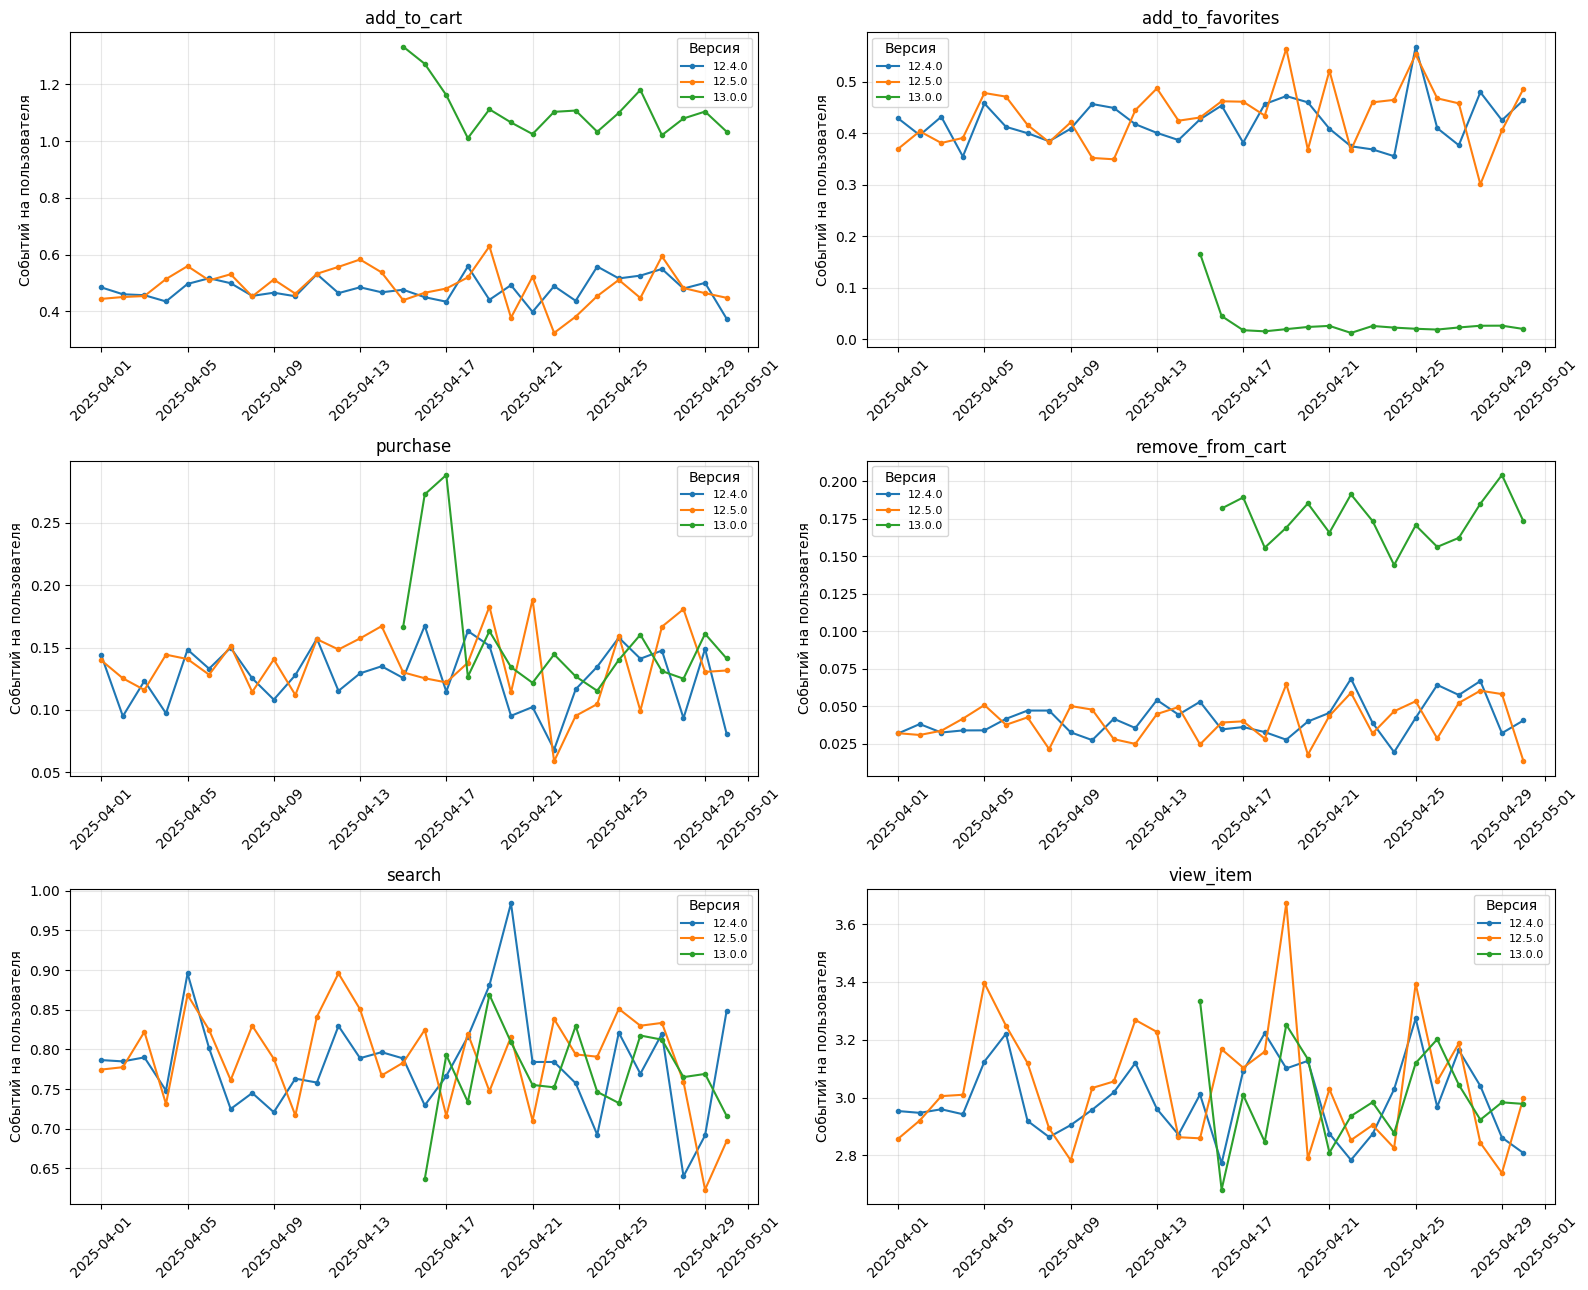

app_version,12.4.0,12.5.0,13.0.0
event,,,
add_to_cart,0.486,0.473,1.075
add_to_favorites,0.433,0.450,0.022
purchase,0.123,0.135,0.138
remove_from_cart,0.044,0.043,0.172
search,0.791,0.777,0.777
view_item,3.010,3.035,3.007


In [8]:
android = df[df['platform'] == 'Android'].copy()

users = (
    android.groupby(['date', 'app_version'])['user_id']
    .nunique()
    .rename('users')
    .reset_index()
)

event_stats = (
    android.groupby(['date', 'app_version', 'event'])
    .size()
    .rename('events')
    .reset_index()
    .merge(users, on=['date', 'app_version'])
)
event_stats['avg_per_user'] = event_stats['events'] / event_stats['users']

all_events = sorted(android['event'].unique())
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for ax, event_name in zip(axes.ravel(), all_events):
    tmp = event_stats[event_stats['event'] == event_name]
    pivot = tmp.pivot(index='date', columns='app_version', values='avg_per_user')

    for version in pivot.columns:
        ax.plot(pivot.index, pivot[version], marker='o', markersize=3, label=version)

    ax.set_title(event_name)
    ax.set_ylabel('Событий на пользователя')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(title='Версия', fontsize=8)

plt.tight_layout()
plt.show()

post_release = (
    event_stats[event_stats['date'] >= cutoff]
    .groupby(['event', 'app_version'])['avg_per_user']
    .mean()
    .unstack()
    .round(3)
)
post_release


**Вывод и гипотеза.** Если посмотреть все события на Android по версиям, то у `13.0.0` одновременно меняются несколько вещей:

- `add_to_cart` вырос примерно до 1.08 события на пользователя;
- `add_to_favorites` почти пропал — около 0.02 вместо 0.43–0.45;
- `remove_from_cart` вырос примерно до 0.17 вместо 0.04.

При этом `view_item`, `search` и `purchase` выглядят примерно как раньше.

Из этого я бы предположил, что в версии Android `13.0.0` что-то сломалось около favorites. Например, кнопка добавления в избранное могла начать добавлять товар в корзину, либо само избранное перестало нормально работать и люди начали временно складывать товары в корзину.



#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

### Сообщение команде

Вечер в хату, друзья! Кажется, я разобрался с существующей проблемой!

Примерно с 18 апреля конверсия `add_to_cart -> purchase` упала с ~31% до ~23%. Но при этом `view -> purchase` осталась примерно на прежнем уровне, около 10%. То есть проблема не в том, что люди резко перестали покупать. Наоборот, стало аномально много событий добавления в корзину.

Дальше я посмотрел по платформам и версиям. И остановился на **Android 13.0.0**. На этой версии `add_to_cart` на пользователя примерно в два раза выше, чем раньше. `add_to_favorites` почти полностью исчезает, а `remove_from_cart` становится почти в 4 раза больше.

Задумываюсь о том, что действие «добавить в избранное» начало работать как «добавить в корзину», либо пользователям пришлось использовать корзину вместо избранного. Я бы сначала проверил изменения, которые вошли в релиз 13.0.0, особенно логику кнопок корзины и избранного и отправку соответствующих событий в аналитику.